In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import h5py

In [21]:
ode = Trajectory1PAT1R()

In [22]:
with h5py.File("ForcingTermsWaSABI1PAT1R.h5", "r") as trajectoryData:
    p, m1, m2, chi1, chi2, deltaM = np.array(trajectoryData["Grid"][:]).T
    dOmegadp = -3./2.*p**(-5./2.)
    nu = m1*m2/(m1+m2)**2.
    FOmega_WaSABI = np.array(trajectoryData["dOmega/dt"][:])
    Fp_WaSABI = FOmega_WaSABI/dOmegadp
    Omega_WaSABI = np.array(trajectoryData["dphi/dt"][:])
    Fnu_WaSABI = np.array(trajectoryData["dnu/dt"][:])
    FdeltaM_WaSABI = np.array(trajectoryData["ddeltam/dt"][:])
    Fchit1_WaSABI = np.array(trajectoryData["dchit1/dt"][:])
    N_TESTS = len(p)

In [23]:
ode_values = []
for i in range(N_TESTS):
    ode.add_fixed_parameters(m1[i], m2[i], chi1[i], [chi2[i]])
    ode_values.append(ode.evaluate_rhs([p[i], 0.0, 1.0, 0.0, 0.0, 0.0, deltaM[i], 0.0]))
ode_values = np.array(ode_values)

Fp_RelativeError = np.abs(1 - nu*ode_values[:,0]/Fp_WaSABI)
FdeltaM_RelativeError = np.abs(1 - nu*ode_values[:,-2]/FdeltaM_WaSABI)
Fchit1_RelativeError = np.abs(1 - nu*ode_values[:,-1]/Fchit1_WaSABI)

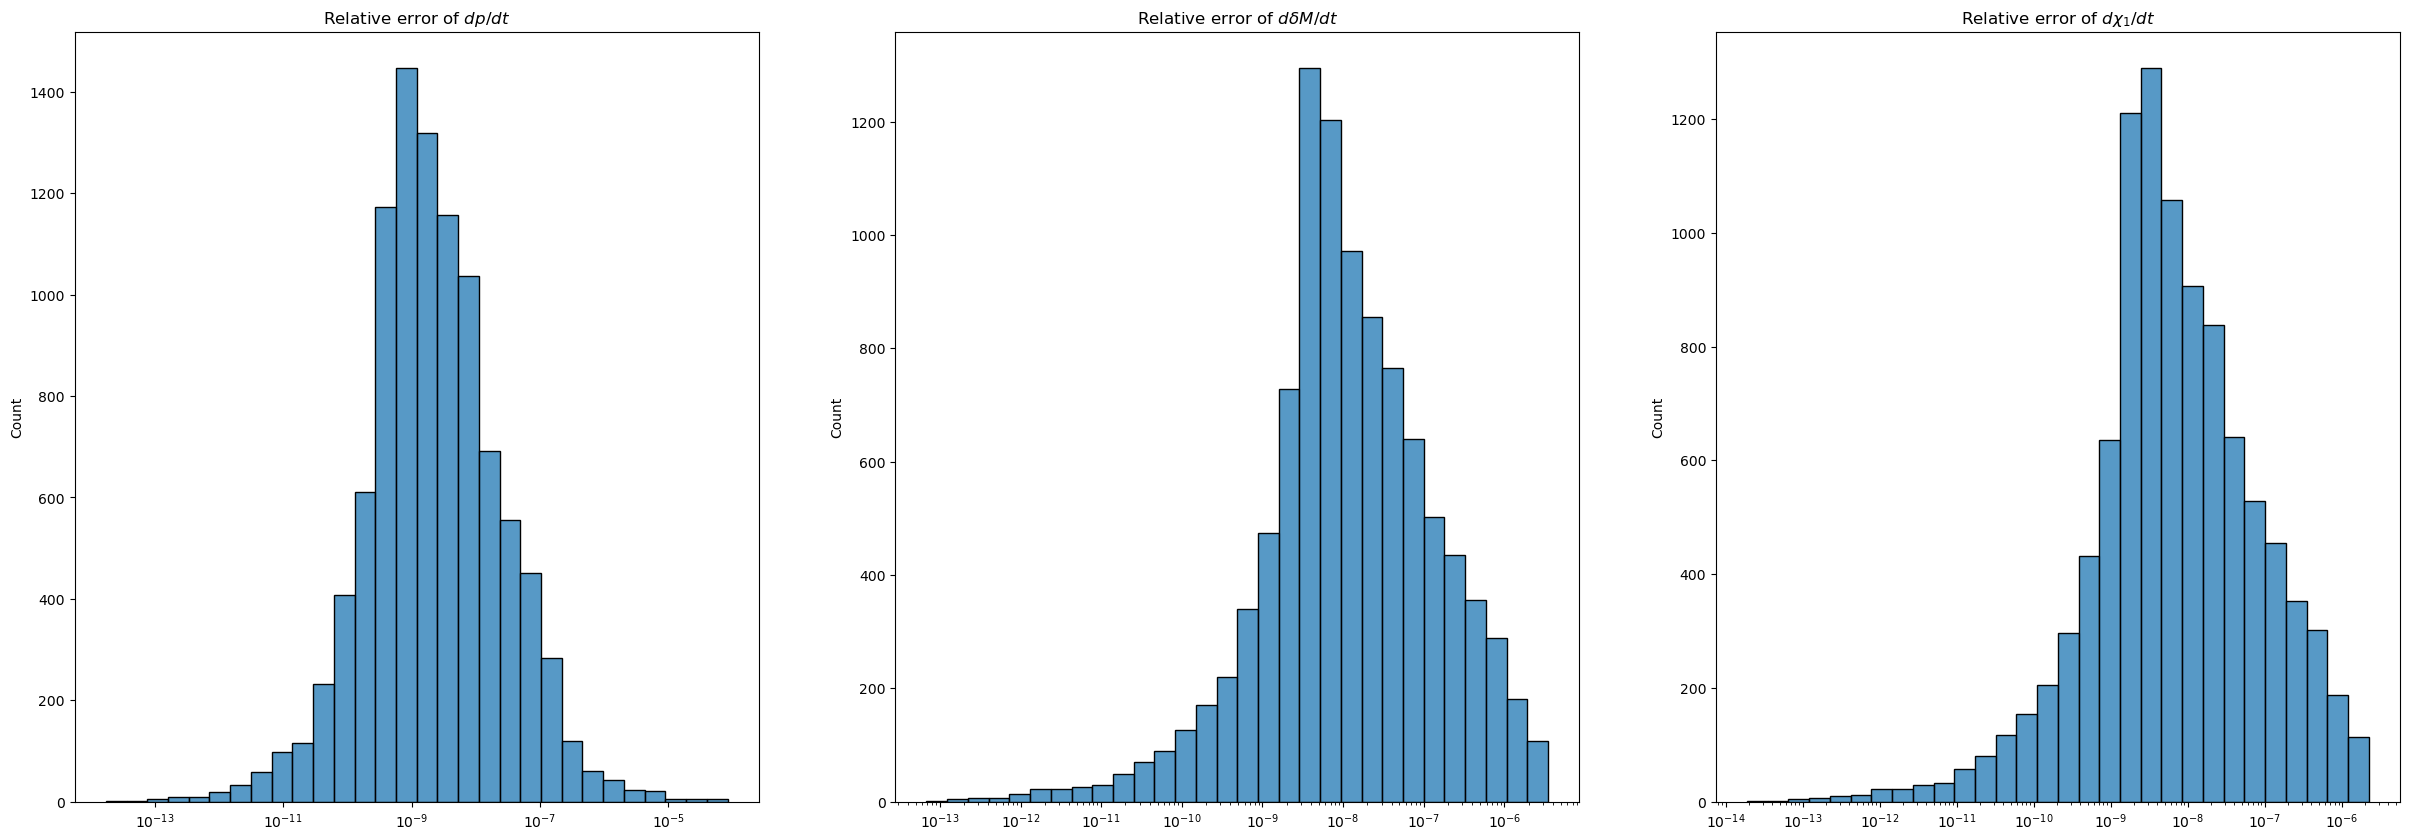

In [24]:
fig, axs = plt.subplots(1,3,figsize=(30,10))

sns.histplot(Fp_RelativeError, bins=30, log_scale=True, ax=axs[0])
axs[0].set(title=rf'Relative error of $dp/dt$')
sns.histplot(FdeltaM_RelativeError, bins=30, log_scale=True, ax=axs[1])
axs[1].set(title=rf'Relative error of $d\delta M/dt$')
sns.histplot(Fchit1_RelativeError, bins=30, log_scale=True, ax=axs[2])
axs[2].set(title=rf'Relative error of $d\chi_1/dt$')

plt.show()